# Project 4 — Notebook 14: City Deep Dive
### P3.2 Breach Concentration · Endorsement Delay · CBD vs Non-CBD · UNKNOWN Ticket Rate

---

| | |
|---|---|
| **Scope** | NCR (Region 3) · Reactive tickets (Priority 1–3) · City-level operational friction |
| **Feeds from** | NB13 (City Performance Landscape) · `output/cleaned_fault_ticket.csv` |
| **Audience** | Operations Leadership / Area Heads / Team Leads |

---

**Questions this notebook answers:**
1. Which cities are driving the P3.2 degradation breach problem identified in Project 3?
2. Does endorsement delay (`DISPATCH_DELAY_HOURS`) cluster in specific cities — and does that align with day-off mobilisation friction under the 'Site ko, sagot ko' model?
3. Is Zone 5's elevated field time concentrated in CBD cities (Makati, Taguig/BGC) or broadly distributed?
4. Which cities have the highest UNKNOWN-Under Investigation ticket rates — where is RFO data quality worst?

## 1. Setup
from fault_ticket_plots import plot_city_metric_by_zone

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE, SLA_THRESHOLDS
from src.visualization.common_plots import plot_heatmap
from src.visualization.fault_ticket_plots import plot_city_metric_by_zone

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()
clean   = df_zone[df_zone['Timestamp_Integrity']].copy()

MIN_CITY_TICKETS = 50
city_vol    = df_zone.groupby(['ZONE','CITY']).size().reset_index(name='Tickets')
valid_cities = city_vol[city_vol['Tickets'] >= MIN_CITY_TICKETS][['ZONE','CITY']]
df_city      = df_zone.merge(valid_cities, on=['ZONE','CITY'])
clean_city   = clean.merge(valid_cities, on=['ZONE','CITY'])

# P3.2 tickets only (Degradation · 12h SLA)
df_p32 = df_city[df_city['Priority_Urgency'] == 3.2].copy()

# UNKNOWN RFO tickets
df_unk = df_city[df_city['Standardized RFO'] == 'UNKNOWN-Under Investigation'].copy()

print(f"✅ {len(df_city):,} city-filtered reactive tickets")
print(f"   P3.2 (Degradation) tickets: {len(df_p32):,}")
print(f"   UNKNOWN RFO tickets:         {len(df_unk):,}  ({len(df_unk)/len(df_city)*100:.1f}%)")
print(f"   Timestamp-clean tickets:     {len(clean_city):,}")

✅ 36,847 city-filtered reactive tickets
   P3.2 (Degradation) tickets: 5,168
   UNKNOWN RFO tickets:         5,124  (13.9%)
   Timestamp-clean tickets:     35,523


## 2. P3.2 Breach Rate by City

> P3.2 = BTS-level degradation alarms · 12h SLA target.
> This was the dominant breach category across all zones in Project 3 (31.6–44.2% breach rate).
> Here we identify which specific cities are driving those zone-level rates.
>
> **Operational context:** P3.2 tickets are typically deprioritised relative to P3.1 outages.
> Under 'Site ko, sagot ko', a day-off endorsement for a degradation alarm can consume
> several hours of the 12h window before dispatch begins — leaving very little time for
> actual field resolution.

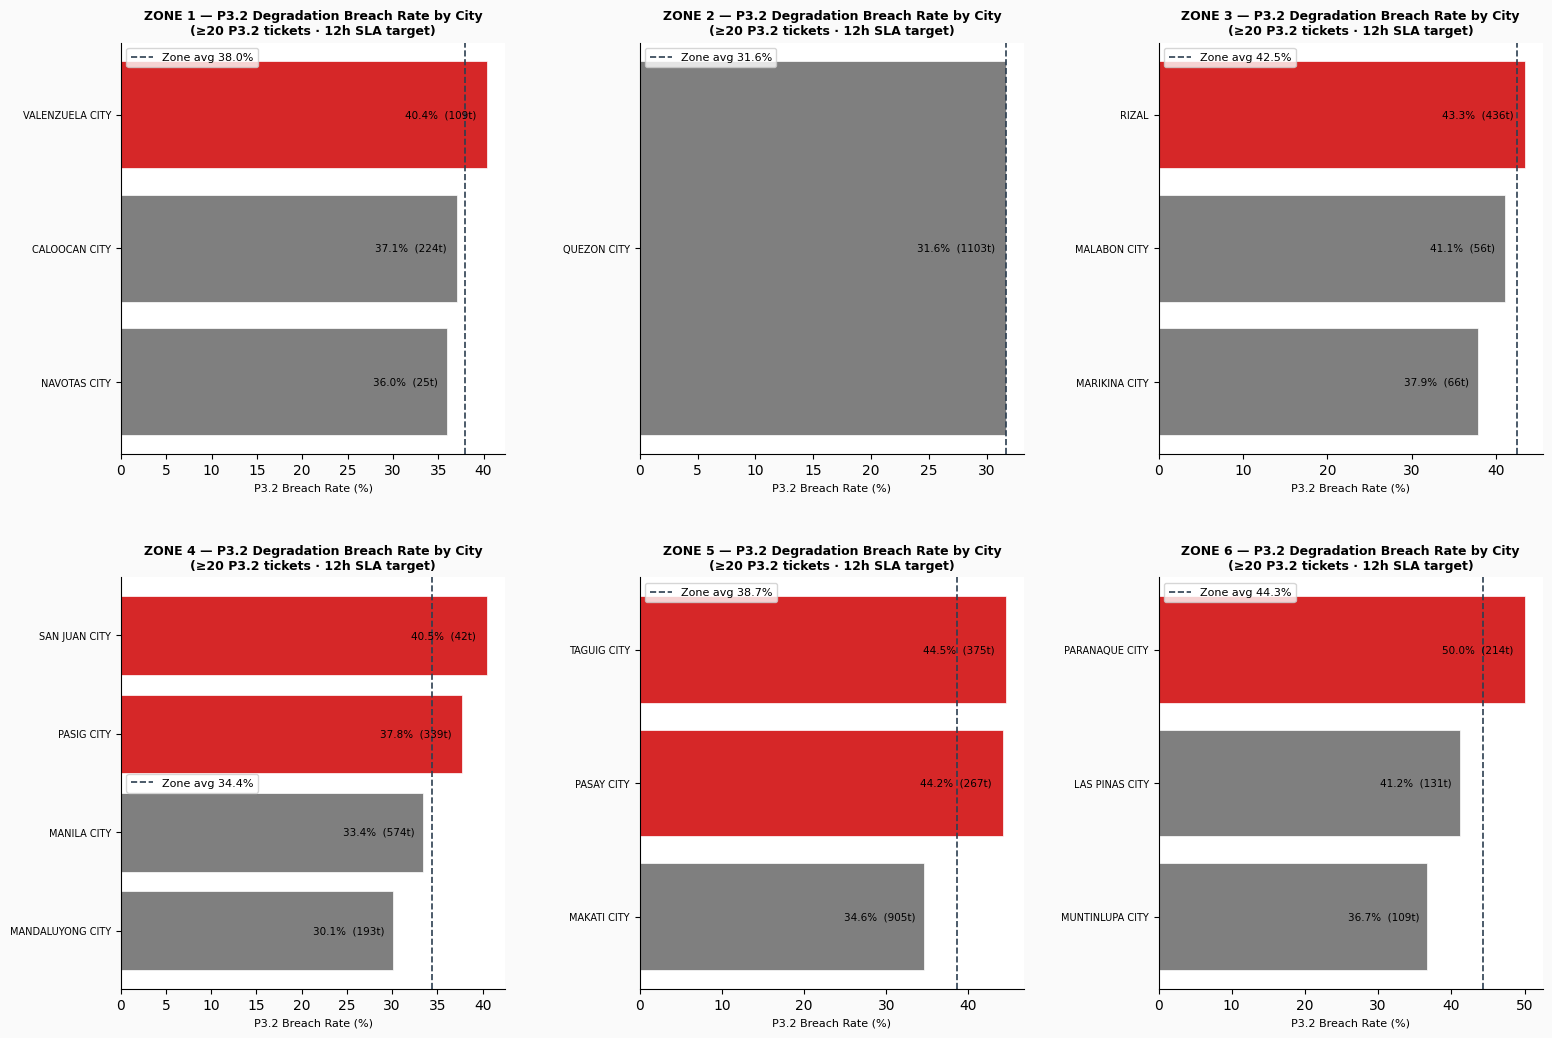


Top 10 cities by P3.2 breach rate (≥20 tickets):
  ZONE            CITY  P32_Tickets  P32_Breach  P32_MTTR
ZONE 6  PARANAQUE CITY          214        50.0     182.8
ZONE 5     TAGUIG CITY          375        44.5     267.6
ZONE 5      PASAY CITY          267        44.2     240.9
ZONE 3           RIZAL          436        43.3      50.6
ZONE 6  LAS PINAS CITY          131        41.2     178.5
ZONE 3    MALABON CITY           56        41.1      80.2
ZONE 4   SAN JUAN CITY           42        40.5     518.0
ZONE 1 VALENZUELA CITY          109        40.4      60.1
ZONE 3   MARIKINA CITY           66        37.9      14.0
ZONE 4      PASIG CITY          339        37.8      89.6


In [2]:
# P3.2 breach rate per city (≥20 P3.2 tickets)
p32_city = (df_p32
    .groupby(['ZONE','CITY'])
    .agg(
        P32_Tickets = ('SLA_Compliant', 'count'),
        P32_Breach  = ('SLA_Compliant', lambda x: (1 - x.mean()) * 100),
        P32_MTTR    = ('OUTAGEDURATION', 'mean'),
    )
    .reset_index()
    .query('P32_Tickets >= 20')
    .sort_values('P32_Breach', ascending=False)
)

# Zone-level P3.2 breach for reference line
zone_p32_breach = (df_p32.groupby('ZONE')['SLA_Compliant']
                   .agg(lambda x: (1 - x.mean()) * 100))

plot_city_metric_by_zone(
    p32_city, ZONE_ORDER,
    value_col    = 'P32_Breach',
    title_tmpl   = '{zone} — P3.2 Degradation Breach Rate by City\n(≥20 P3.2 tickets · 12h SLA target)',
    xlabel       = 'P3.2 Breach Rate (%)',
    color_fn     = lambda v, avg: '#d62728' if v > avg else '#7f7f7f',
    ref_line_fn  = lambda zdf: (zone_p32_breach.get(zdf['ZONE'].iloc[0], float('nan')),
                                f'Zone avg {zone_p32_breach.get(zdf["ZONE"].iloc[0], 0):.1f}%'),
    annotation_fn        = lambda v, t: f'{v:.1f}%  ({int(t)}t)',
    annotation_extra_col = 'P32_Tickets',
    sort_col  = 'P32_Breach',
    save_path = 'reports/figures/project4_ncr/14_p32_breach_by_city.png',
)
plt.show()

print("\nTop 10 cities by P3.2 breach rate (≥20 tickets):")
print(p32_city.head(10)[['ZONE','CITY','P32_Tickets','P32_Breach','P32_MTTR']]
      .to_string(index=False, float_format='{:.1f}'.format))


## 3. Endorsement Delay by City — NOC Contact & Escalation Chain

> `DISPATCH_DELAY_HOURS` = REPORTDATE → DISPATCHDATE.
> Captures NOC triage + the full contact chain: up to 3 attempts to reach the assigned
> engineer, then duty team lead, then area head if unreachable.
>
> Cities with elevated dispatch delay relative to their zone average may indicate
> higher day-off endorsement friction — either chronic scheduling misalignment
> between assigned engineers and their peak fault days, or sites where the assigned
> engineer is frequently unavailable and the escalation chain is regularly invoked.
>
> **Note:** Mobilisation friction does not end at DISPATCHDATE — for day-off scenarios,
> post-endorsement coordination also flows into `FIELD_TIME_HOURS`. See Section 4.

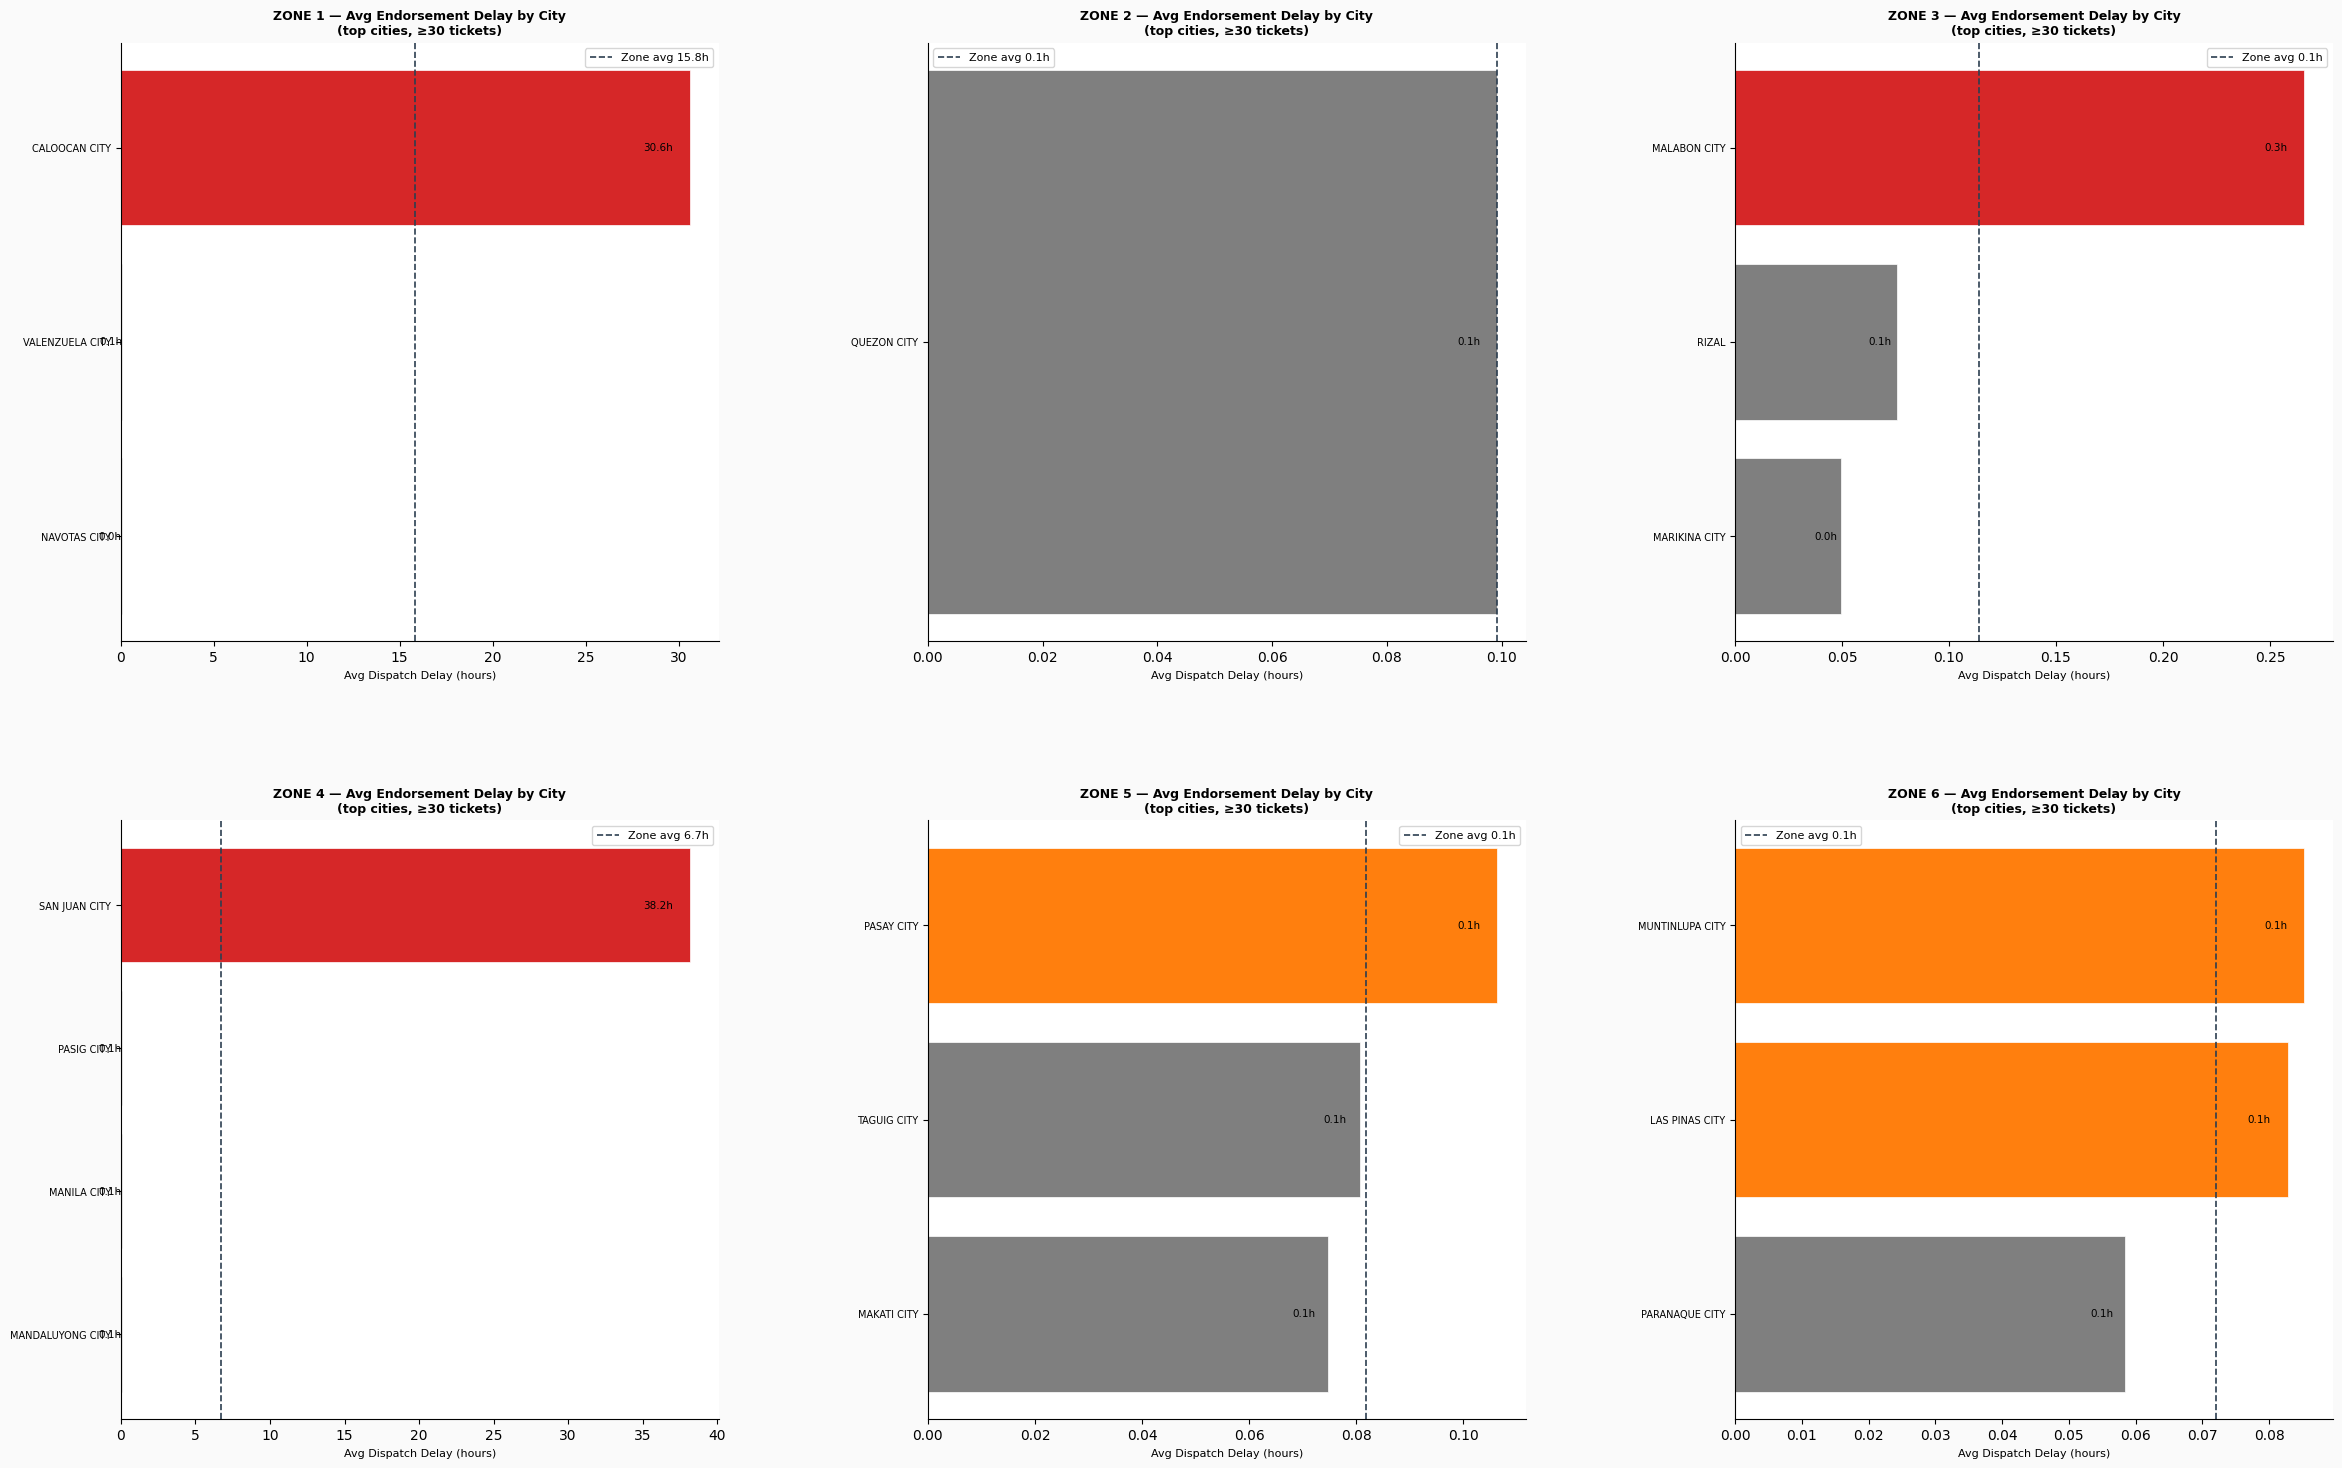


Top 10 cities by avg endorsement delay (≥30 clean tickets):
  ZONE            CITY  Tickets  Avg_NOC_Time  Med_NOC_Time
ZONE 4   SAN JUAN CITY     1337          38.2           0.0
ZONE 1   CALOOCAN CITY     2124          30.6           0.0
ZONE 3    MALABON CITY      949           0.3           0.0
ZONE 5      PASAY CITY     1537           0.1           0.0
ZONE 2     QUEZON CITY     7092           0.1           0.0
ZONE 6 MUNTINLUPA CITY     1006           0.1           0.0
ZONE 6  LAS PINAS CITY      947           0.1           0.0
ZONE 5     TAGUIG CITY     2266           0.1           0.0
ZONE 3           RIZAL     2621           0.1           0.0
ZONE 5     MAKATI CITY     4939           0.1           0.0


In [3]:
# NOC/endorsement delay by city — timestamp-clean tickets
noc_city = (clean_city
    .groupby(['ZONE','CITY'])
    .agg(
        Tickets      = ('DISPATCH_DELAY_HOURS', 'count'),
        Avg_NOC_Time = ('DISPATCH_DELAY_HOURS', 'mean'),
        Med_NOC_Time = ('DISPATCH_DELAY_HOURS', 'median'),
    )
    .reset_index()
    .query('Tickets >= 30')
)

zone_noc_avg = clean_city.groupby('ZONE')['DISPATCH_DELAY_HOURS'].mean()
noc_city['Avg_NOC_Time_capped'] = noc_city['Avg_NOC_Time'].clip(upper=40)
noc_city['CITY'] = noc_city['CITY'].str.replace('CITY OF ', '', regex=False)

plot_city_metric_by_zone(
    noc_city, ZONE_ORDER,
    value_col    = 'Avg_NOC_Time_capped',
    title_tmpl   = '{zone} — Avg Endorsement Delay by City\n(top cities, ≥30 tickets)',
    xlabel       = 'Avg Dispatch Delay (hours)',
    color_fn     = lambda v, avg: ('#d62728' if v > avg * 1.5 else
                                   '#ff7f0e' if v > avg else '#7f7f7f'),
    ref_line_fn  = lambda zdf: (zone_noc_avg.get(zdf['ZONE'].iloc[0], float('nan')),
                                f'Zone avg {zone_noc_avg.get(zdf["ZONE"].iloc[0], 0):.1f}h'),
    annotation_fn = lambda v, _: f'{v:.1f}h',
    sort_col  = 'Avg_NOC_Time_capped',
    top_n     = 10,
    figsize=(28, 16),
    save_path = 'reports/figures/project4_ncr/14_endorsement_delay_by_city.png',
)
plt.show()

print("\nTop 10 cities by avg endorsement delay (≥30 clean tickets):")
print(noc_city.sort_values('Avg_NOC_Time', ascending=False).head(10)
      [['ZONE','CITY','Tickets','Avg_NOC_Time','Med_NOC_Time']]
      .to_string(index=False, float_format='{:.1f}'.format))


## 4. Zone 5 — CBD vs Non-CBD Field Time Split

> Zone 5 has the highest field time in NCR (131.8h avg). The hypothesis from Projects 1–3
> is that CBD permit friction in Makati and Taguig/BGC is driving this.
> This section tests that directly by splitting Zone 5 cities into CBD and non-CBD groups.
>
> **CBD cities in Zone 5:** Makati City, Taguig City (BGC), Pasay City, Pateros
> (adjust list based on your site database — these are the known permit-friction cities)
>
> **Expected finding:** If CBD cities show materially higher field time than non-CBD
> cities within Zone 5, the intervention is permit pre-coordination — not additional
> technicians. If the difference is small, the problem is more broadly distributed.

Zone 5 — CBD vs Non-CBD split:
City_Type  Tickets  Avg_Field_Time  Med_Field_Time  SLA_pct
      CBD     8742            80.4             1.4     78.8


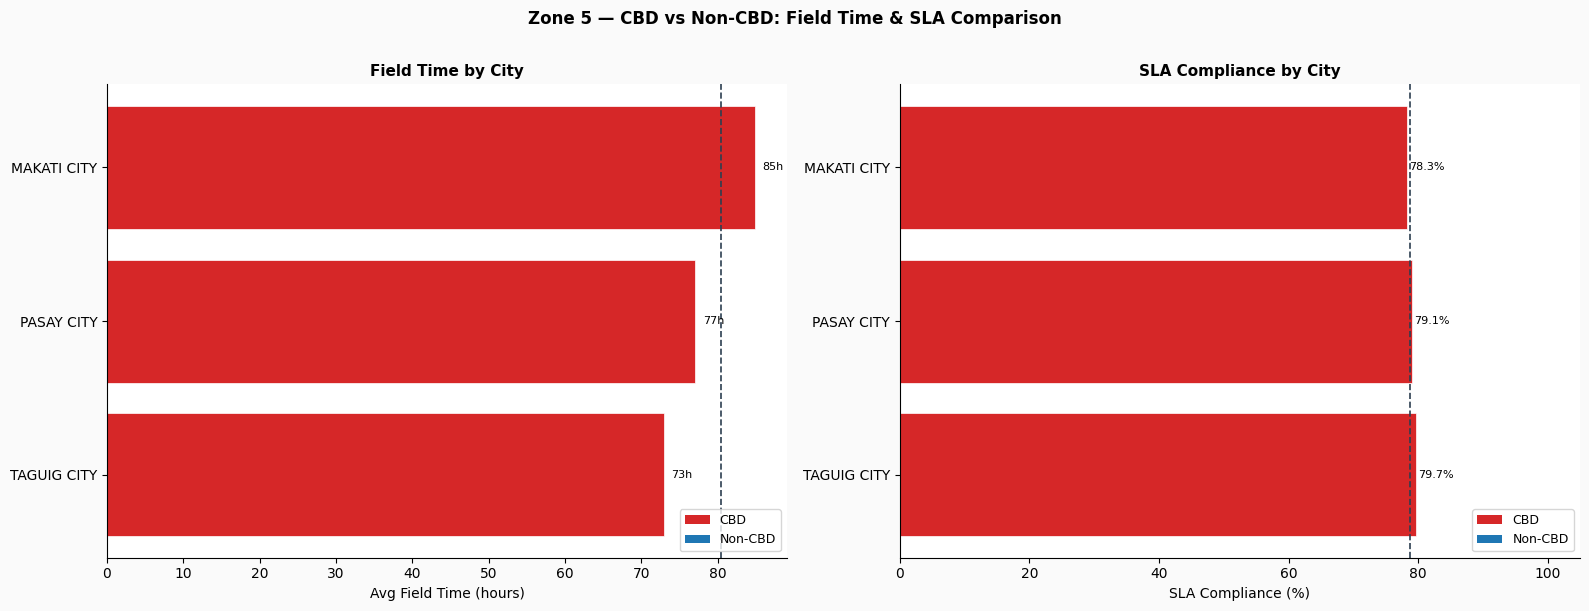

In [4]:
# Zone 5 CBD vs non-CBD field time analysis
# Adjust CBD_CITIES based on actual city names in your data
CBD_CITIES = ['MAKATI CITY', 'TAGUIG CITY', 'PASAY CITY', 'PATEROS']

z5_clean = clean_city[clean_city['ZONE'] == 'ZONE 5'].copy()
z5_clean['City_Type'] = z5_clean['CITY'].apply(
    lambda c: 'CBD' if c.upper() in CBD_CITIES else 'Non-CBD'
)

# Field time by city type
cbd_split = (z5_clean
    .groupby('City_Type')
    .agg(
        Tickets        = ('FIELD_TIME_HOURS', 'count'),
        Avg_Field_Time = ('FIELD_TIME_HOURS', 'mean'),
        Med_Field_Time = ('FIELD_TIME_HOURS', 'median'),
        SLA_pct        = ('SLA_Compliant',   'mean'),
    )
    .reset_index()
)
cbd_split['SLA_pct'] *= 100

print("Zone 5 — CBD vs Non-CBD split:")
print(cbd_split.to_string(index=False, float_format='{:.1f}'.format))

# Per-city breakdown within Zone 5
z5_by_city = (z5_clean
    .groupby(['CITY','City_Type'])
    .agg(
        Tickets        = ('FIELD_TIME_HOURS', 'count'),
        Avg_Field_Time = ('FIELD_TIME_HOURS', 'mean'),
        Avg_NOC_Time   = ('DISPATCH_DELAY_HOURS', 'mean'),
        SLA_pct        = ('SLA_Compliant',   'mean'),
    )
    .reset_index()
    .sort_values('Avg_Field_Time', ascending=False)
)
z5_by_city['SLA_pct'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('Zone 5 — CBD vs Non-CBD: Field Time & SLA Comparison',
             fontsize=12, fontweight='bold', y=1.01)

cbd_colors  = {'CBD': '#d62728', 'Non-CBD': '#1f77b4'}
city_colors = [cbd_colors[t] for t in z5_by_city['City_Type']]

# [Left] Field time by city
bars = axes[0].barh(z5_by_city['CITY'], z5_by_city['Avg_Field_Time'],
                     color=city_colors, edgecolor='white', linewidth=0.5)
ncr_field_avg = z5_clean['FIELD_TIME_HOURS'].mean()
axes[0].axvline(ncr_field_avg, color='#2c3e50', linestyle='--',
                 linewidth=1.2, label=f'Zone 5 avg {ncr_field_avg:.0f}h')
for bar, val in zip(bars, z5_by_city['Avg_Field_Time']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                  f'{val:.0f}h', va='center', fontsize=8)
axes[0].set_xlabel('Avg Field Time (hours)', fontsize=10)
axes[0].set_title('Field Time by City', fontsize=11, fontweight='bold', pad=6)
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#d62728', label='CBD'), Patch(facecolor='#1f77b4', label='Non-CBD')]
axes[0].legend(handles=legend_els, fontsize=9, loc='lower right')

# [Right] SLA by city
bars2 = axes[1].barh(z5_by_city['CITY'], z5_by_city['SLA_pct'],
                      color=city_colors, edgecolor='white', linewidth=0.5)
z5_sla = z5_clean['SLA_Compliant'].mean() * 100
axes[1].axvline(z5_sla, color='#2c3e50', linestyle='--',
                 linewidth=1.2, label=f'Zone 5 avg {z5_sla:.1f}%')
for bar, val in zip(bars2, z5_by_city['SLA_pct']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_xlim(0, 105)
axes[1].set_xlabel('SLA Compliance (%)', fontsize=10)
axes[1].set_title('SLA Compliance by City', fontsize=11, fontweight='bold', pad=6)
axes[1].legend(handles=legend_els, fontsize=9, loc='lower right')
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project4_ncr/14_z5_cbd_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
cbd_avg     = cbd_split[cbd_split['City_Type']=='CBD']['Avg_Field_Time'].values
noncbd_avg  = cbd_split[cbd_split['City_Type']=='Non-CBD']['Avg_Field_Time'].values
if len(cbd_avg) and len(noncbd_avg):
    diff = cbd_avg[0] - noncbd_avg[0]
    print(f"\nCBD avg field time:     {cbd_avg[0]:.0f}h")
    print(f"Non-CBD avg field time: {noncbd_avg[0]:.0f}h")
    print(f"Delta:                  {diff:+.0f}h")
    if diff > 20:
        print("→ CBD friction is a material driver. Intervention: permit pre-coordination.")
    elif diff > 5:
        print("→ CBD friction is a contributing factor but not the sole driver.")
    else:
        print("→ CBD/non-CBD difference is small. Problem is broadly distributed across Zone 5.")

## 5. UNKNOWN-Under Investigation Ticket Rate by City

> 5,129 tickets (13.9% of NCR) have 'UNKNOWN-Under Investigation' as their RFO.
> These are excluded from fault-type analysis because their root cause is unresolved.
> Their anomalously high SLA compliance (92.7%) suggests many may be auto-closed
> or timed-out without proper investigation.
>
> Cities with high UNKNOWN rates have the least reliable RFO data — interventions
> in those cities based on RFO-type analysis will be less accurate.

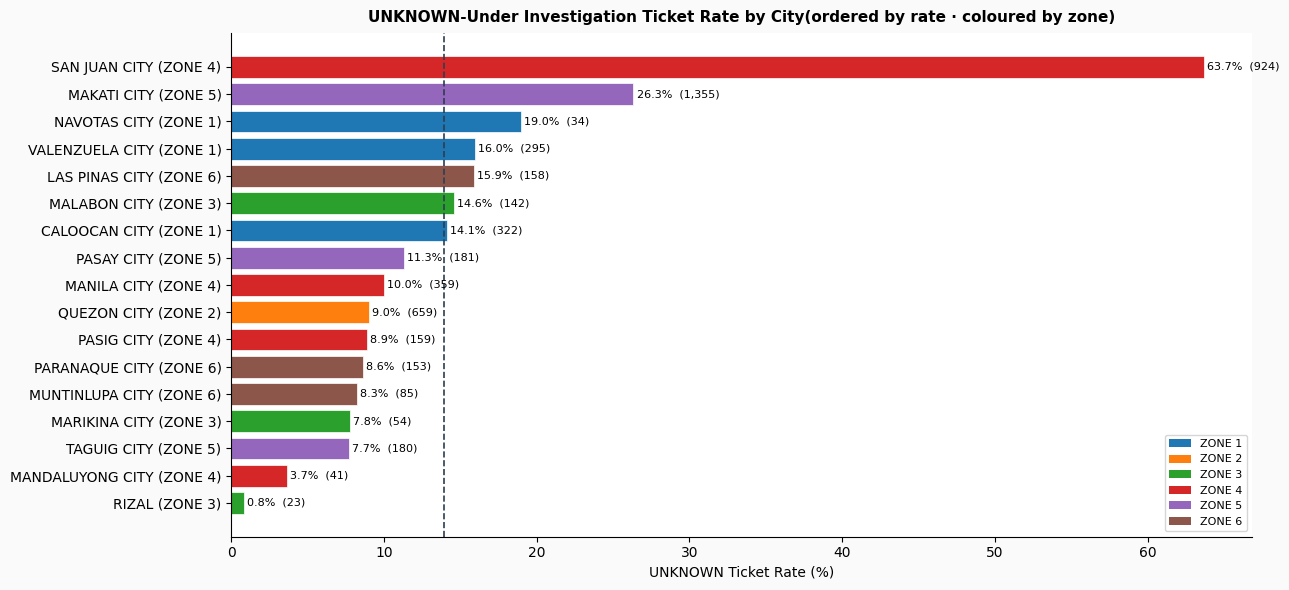


NCR-wide UNKNOWN rate: 13.9%

Top 10 cities by UNKNOWN rate:
  ZONE            CITY  Total_Tickets  Unknown_Tickets  Unknown_Rate
ZONE 4   SAN JUAN CITY           1451              924          63.7
ZONE 5     MAKATI CITY           5145             1355          26.3
ZONE 1    NAVOTAS CITY            179               34          19.0
ZONE 1 VALENZUELA CITY           1845              295          16.0
ZONE 6  LAS PINAS CITY            996              158          15.9
ZONE 3    MALABON CITY            974              142          14.6
ZONE 1   CALOOCAN CITY           2282              322          14.1
ZONE 5      PASAY CITY           1601              181          11.3
ZONE 4     MANILA CITY           3589              359          10.0
ZONE 2     QUEZON CITY           7307              659           9.0


In [5]:
# UNKNOWN ticket rate by city
unk_city = (df_city
    .groupby(['ZONE','CITY'])
    .agg(
        Total_Tickets   = ('SLA_Compliant',     'count'),
        Unknown_Tickets = ('Standardized RFO',  lambda x: (x == 'UNKNOWN-Under Investigation').sum()),
    )
    .reset_index()
)
unk_city['Unknown_Rate'] = unk_city['Unknown_Tickets'] / unk_city['Total_Tickets'] * 100
unk_city = unk_city[unk_city['Total_Tickets'] >= MIN_CITY_TICKETS].sort_values('Unknown_Rate', ascending=False)

# NCR-wide unknown rate
ncr_unk_rate = len(df_unk) / len(df_city) * 100

fig, ax = plt.subplots(figsize=(13, max(6, len(unk_city) * 0.35)))
fig.patch.set_facecolor('#fafafa')

colors = [ZONE_PALETTE.get(z, '#7f7f7f') for z in unk_city['ZONE']]
labels = [f"{row['CITY']} ({row['ZONE']})" for _, row in unk_city.iterrows()]

bars = ax.barh(labels, unk_city['Unknown_Rate'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(ncr_unk_rate, color='#2c3e50', linestyle='--',
            linewidth=1.2, label=f'NCR avg {ncr_unk_rate:.1f}%')
for bar, val, t in zip(bars, unk_city['Unknown_Rate'], unk_city['Unknown_Tickets']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%  ({t:,})', va='center', fontsize=8)

ax.set_xlabel('UNKNOWN Ticket Rate (%)', fontsize=10)
ax.set_title('UNKNOWN-Under Investigation Ticket Rate by City'
              '(ordered by rate · coloured by zone)',
              fontsize=11, fontweight='bold', pad=8)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
zone_patches = [Patch(facecolor=ZONE_PALETTE[z], label=z) for z in ZONE_ORDER
                if z in unk_city['ZONE'].values]
ax.legend(handles=zone_patches, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('reports/figures/project4_ncr/14_unknown_rate_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNCR-wide UNKNOWN rate: {ncr_unk_rate:.1f}%")
print(f"\nTop 10 cities by UNKNOWN rate:")
print(unk_city.head(10)[['ZONE','CITY','Total_Tickets','Unknown_Tickets','Unknown_Rate']]
      .to_string(index=False, float_format='{:.1f}'.format))

## 6. Combined City Risk Matrix

> Plotting each city on two dimensions:
> - X axis: SLA breach rate (higher = worse)
> - Y axis: Fault density (higher = more repeated faults)
>
> Cities in the top-right quadrant are the highest-priority intervention targets:
> high breach rate AND high fault density. Cities in the top-left have high fault density
> but adequate SLA — likely manageable with preventive maintenance (Project 5).
> Cities bottom-right have low density but poor SLA — likely an endorsement or
> field capacity problem rather than a recurrence problem.

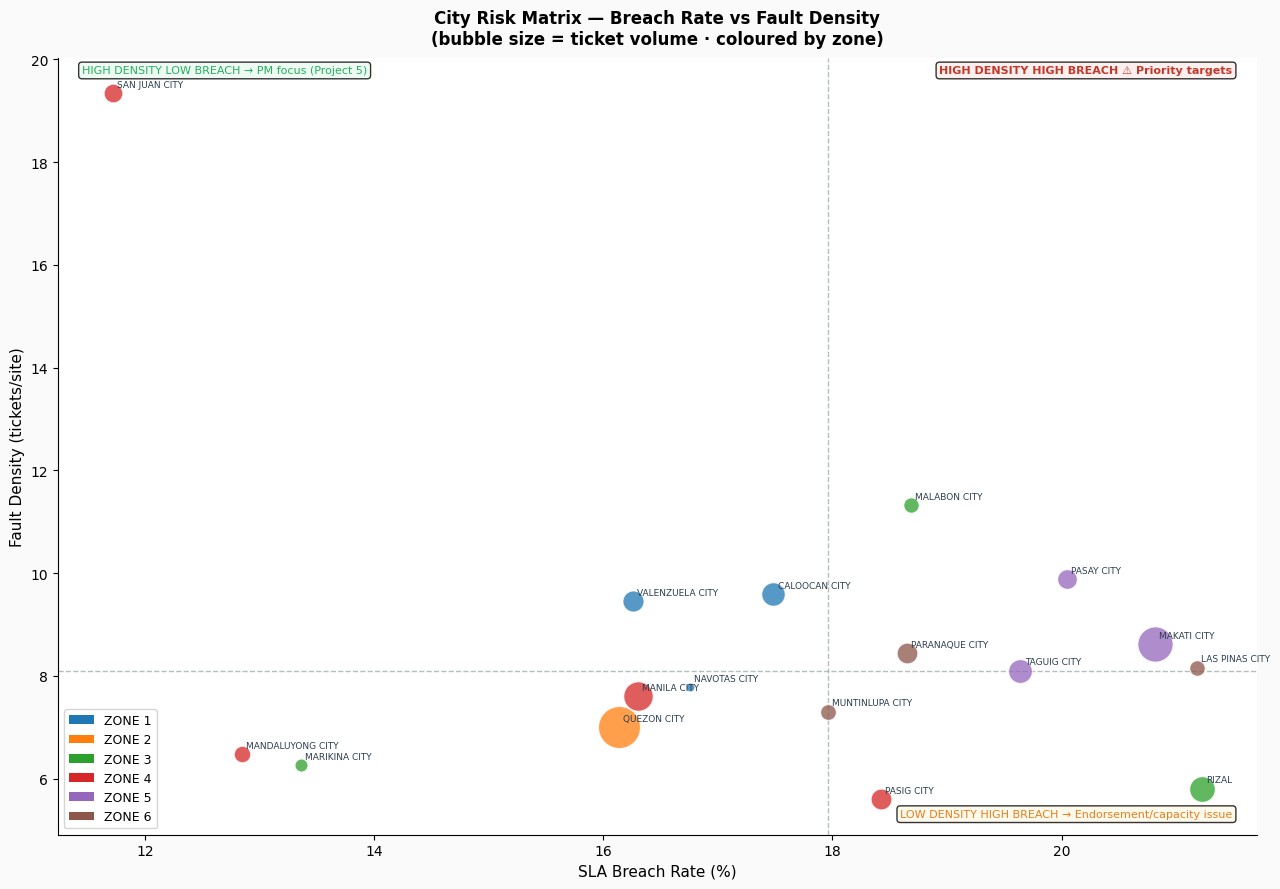

Priority targets (high breach + high density) — 5 cities:
  ZONE           CITY  Tickets  Breach_Rate  Fault_Density
ZONE 6 LAS PINAS CITY      996         21.2            8.2
ZONE 5    MAKATI CITY     5145         20.8            8.6
ZONE 5     PASAY CITY     1601         20.0            9.9
ZONE 3   MALABON CITY      974         18.7           11.3
ZONE 6 PARANAQUE CITY     1775         18.6            8.5


In [6]:
# City risk matrix: breach rate vs fault density
city_risk = (df_city
    .groupby(['ZONE','CITY'])
    .agg(
        Tickets      = ('SLA_Compliant', 'count'),
        Breach_Rate  = ('SLA_Compliant', lambda x: (1 - x.mean()) * 100),
        Fault_Density= ('SiteName',      lambda x: len(x) / x.nunique()),
    )
    .reset_index()
    .query('Tickets >= 50')
)

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#fafafa')

for _, row in city_risk.iterrows():
    color = ZONE_PALETTE.get(row['ZONE'], '#7f7f7f')
    ax.scatter(row['Breach_Rate'], row['Fault_Density'],
                s=max(40, row['Tickets'] / 8),
                color=color, alpha=0.75, edgecolors='white', linewidth=0.8, zorder=3)
    ax.annotate(row['CITY'], (row['Breach_Rate'], row['Fault_Density']),
                 fontsize=6.5, ha='left', va='bottom',
                 xytext=(3, 3), textcoords='offset points', color='#2c3e50')

# Quadrant lines at medians
med_breach  = city_risk['Breach_Rate'].median()
med_density = city_risk['Fault_Density'].median()
ax.axvline(med_breach,  color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(med_density, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels
ax.text(0.98, 0.99, 'HIGH DENSITY HIGH BREACH ⚠ Priority targets',
         transform=ax.transAxes, ha='right', va='top', fontsize=8,
         color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', alpha=0.8))
ax.text(0.02, 0.99, 'HIGH DENSITY LOW BREACH → PM focus (Project 5)',
         transform=ax.transAxes, ha='left', va='top', fontsize=8,
         color='#27ae60',
         bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', alpha=0.8))
ax.text(0.98, 0.02, 'LOW DENSITY HIGH BREACH → Endorsement/capacity issue',
         transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
         color='#e67e22',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fef9e7', alpha=0.8))

ax.set_xlabel('SLA Breach Rate (%)', fontsize=11)
ax.set_ylabel('Fault Density (tickets/site)', fontsize=11)
ax.set_title('City Risk Matrix — Breach Rate vs Fault Density\n'
              '(bubble size = ticket volume · coloured by zone)',
              fontsize=12, fontweight='bold', pad=10)

from matplotlib.patches import Patch
zone_patches = [Patch(facecolor=ZONE_PALETTE[z], label=z) for z in ZONE_ORDER]
ax.legend(handles=zone_patches, fontsize=9, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project4_ncr/14_city_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top-right quadrant cities
priority_targets = city_risk[
    (city_risk['Breach_Rate']   > med_breach) &
    (city_risk['Fault_Density'] > med_density)
].sort_values('Breach_Rate', ascending=False)

print(f"Priority targets (high breach + high density) — {len(priority_targets)} cities:")
print(priority_targets[['ZONE','CITY','Tickets','Breach_Rate','Fault_Density']]
      .to_string(index=False, float_format='{:.1f}'.format))

## 7. Next Steps

→ **Notebook 15** — Project 4 Business Summary & Recommendations:
city-level findings, targeted interventions per city tier, next steps to Project 5 (Site Risk Profiling).